# Reading Data
## ... from a CSV File

In [1]:
import pandas as pd

# Read the CSV file
file_path = "reviews.csv"
data = pd.read_csv(file_path)

# Extract the text column
reviews = data["Review Text"]

# Print the reviews
print(reviews)

FileNotFoundError: [Errno 2] No such file or directory: 'reviews.csv'

## ... from a Plain Text File

In [ ]:
# Read the text file
## The readlines() method reads all lines into a list, and we iterate over it to print each line without extra whitespace using the strip() method.
file_path = "comments.txt"
with open(file_path, "r") as file:
    lines = file.readlines()

# Print each line
for line in lines:
    print(line.strip())

## ... from JSON

In [ ]:
import json

# Read the JSON file
## After opening the file with open(), we use the json.load() function to parse the JSON content into a Python object (usually a dictionary or list). We then loop through the JSON data to extract and display the text fields.
file_path = "data.json"
with open(file_path, "r") as file:
    data = json.load(file)

# Extract and print text values
for record in data:
    print(record["text"])

In [ ]:
"""
EXAMPLE:
[
    {"id": 1, "text": "This is amazing!"},
    {"id": 2, "text": "Not satisfied with the product."},
    {"id": 3, "text": "Would buy again!"}
]

=> OUTPUT:
This is amazing!
Not satisfied with the product.
Would buy again!
"""

# Common Preprocessing Techniques
## Lowercasing

In [2]:
# Sample text
text = "Natural Language Processing is AMAZING!"

# Convert to lowercase
cleaned_text = text.lower()
print(cleaned_text)

natural language processing is amazing!


## Punctuation Removal

In [3]:
import re

# Sample text
text = "Hello, world! Welcome to NLP."

# Remove punctuation using regex
cleaned_text = re.sub(r"[^\w\s']", "", text)
print(cleaned_text)

Hello world Welcome to NLP


## Removing Extra Whitespaces

In [4]:
# Sample text
text = "  This   is   a   sentence   with   extra   spaces.   "

# Remove extra whitespaces between the words
cleaned_text = " ".join(text.split())

print(cleaned_text)

This is a sentence with extra spaces.


## Removing Numbers

In [5]:
import re

# Sample text
text = "The price is 100 dollars."

# Remove numbers using regex
cleaned_text = re.sub(r"\d+", "", text)
print(cleaned_text)

The price is  dollars.


In [6]:
# Sometimes, we might want to replace or remove specific words.

# Sample text
text = "Stop words like 'and', 'or', and 'but' can be removed."

# Replace specific words
cleaned_text = re.sub(r"\b(and|or|but)\b", "", text)
cleaned_text = " ".join(cleaned_text.split())
print(cleaned_text)

Stop words like '', '', '' can be removed.


## Mehrere Sachen als Funktion
### Lowercasing and Punctuation Removal

In [7]:
import re

def clean_text(text):
    """Clean text by lowercasing and removing punctuation."""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r"[^\w\s']", "", text)
    return text

# Test the function
sample_text = "Hello, NLP World!"
print(clean_text(sample_text))

hello nlp world


### Removing Numbers and Extra Whitespaces

In [8]:
import re

def clean_text_numbers_spaces(text):
    """Clean text by removing numbers and extra spaces."""
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# Test the function
sample_text = "This 123 text   has 456 extra spaces and 789 numbers."
print(clean_text_numbers_spaces(sample_text))

This text has extra spaces and numbers.


## Tokenisierung

In [16]:
import nltk
nltk.download('punkt')  # Download the tokenizer models
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

text = "Natural Language Processing is fascinating!"
tokens = word_tokenize(text)  # Tokenize the text into words
print(tokens)  # Display the tokens

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasmuschket/nltk_data...


['Natural', 'Language', 'Processing', 'is', 'fascinating', '!']


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Stop-Word Removal

Stop words are common words (like "is," "and," "the") that don’t contribute much meaning in text analysis. Removing stop words is essential in applications like search engines, where focusing on significant keywords improves performance.

In [17]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # Download the stop words list

stop_words = set(stopwords.words('english'))  # Get the English stop words
tokens = ['Natural', 'Language', 'Processing', 'is', 'fascinating', '!']
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]  # Remove stop words
print(filtered_tokens)  # Display tokens after stop-word removal

['Natural', 'Language', 'Processing', 'fascinating', '!']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Stemming

Stemming reduces words to their root form by removing suffixes. This is useful in scenarios like document clustering, where grouping similar terms is essential.

In [18]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()  # Initialize the stemmer
filtered_tokens = ['Natural', 'Language', 'Processing', 'fascinating', '!']
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]  # Stem each word
print(stemmed_tokens)  # Display stemmed tokens

['natur', 'languag', 'process', 'fascin', '!']


## Lemmatization

Lemmatization is a more sophisticated process that reduces words to their dictionary (base) form, considering the word's context and meaning. It’s useful in applications like analyzing customer feedback, where retaining meaningful word forms is critical.

In [19]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')  # Download the WordNet data

lemmatizer = WordNetLemmatizer()  # Initialize the lemmatizer
filtered_tokens = ['Natural', 'Language', 'Processing', 'fascinating', '!']
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]  # Lemmatize each word
print(lemmatized_tokens)  # Display lemmatized tokens

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthiasmuschket/nltk_data...


['Natural', 'Language', 'Processing', 'fascinating', '!']


Above output has no differences from the original sentence because the words in the original sentence are already in the dictionary form.

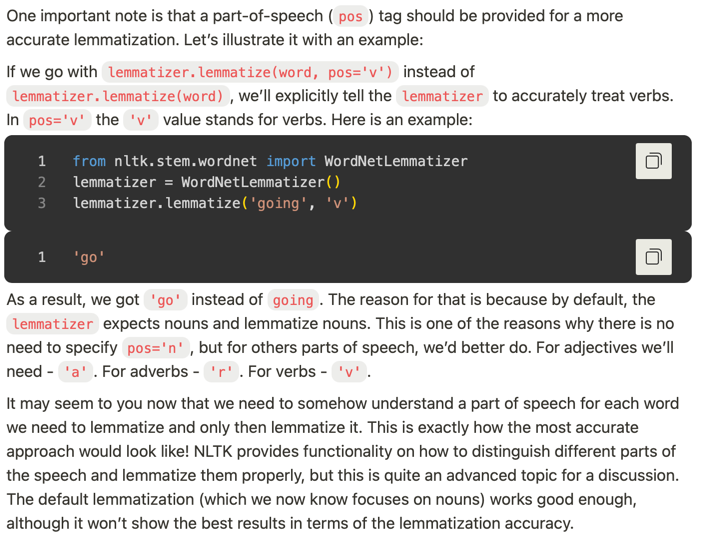

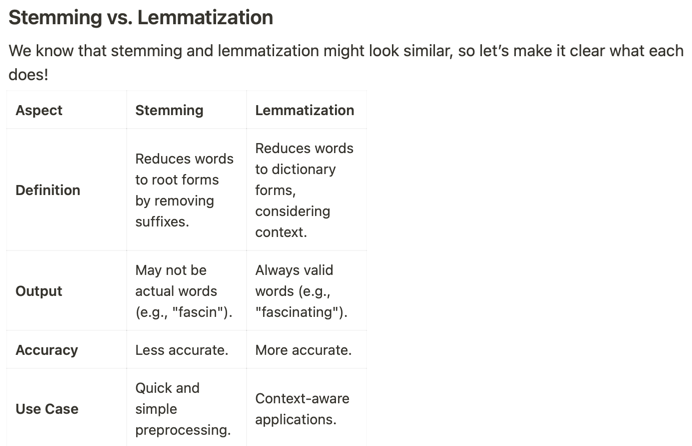

# Vektorisierung
## Bag of Words

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample data
documents = ["I love programming.", "Programming is fun."]

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the documents
X = vectorizer.fit_transform(documents)

# Convert the result to an array and print
print("Vocabulary:", vectorizer.get_feature_names_out())  # Get the vocabulary
print("BoW Matrix:\n", X.toarray())  # Display the document-term matrix

Vocabulary: ['fun' 'is' 'love' 'programming']
BoW Matrix:
 [[0 0 1 1]
 [1 1 0 1]]


Explanation:
- The CountVectorizer converts the text data into a matrix where each column represents a word from the vocabulary.
- The rows represent the individual documents, and the values are the counts of each word in those documents.m

## TF-IDF

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample data
documents = ["I love programming.", "Programming is fun."]

# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the documents
X = vectorizer.fit_transform(documents)

# Convert the result to an array and print
print("Vocabulary:", vectorizer.get_feature_names_out())  # Get the vocabulary
print("TF-IDF Matrix:\n", X.toarray())  # Display the TF-IDF matrix

Vocabulary: ['fun' 'is' 'love' 'programming']
TF-IDF Matrix:
 [[0.         0.         0.81480247 0.57973867]
 [0.6316672  0.6316672  0.         0.44943642]]


Explanation:
The TfidfVectorizer computes the TF-IDF score for each word. The higher the score, the more relevant the word is in that document relative to others.

# ÜBUNGEN

https://app.masterschool.com/campus/lesson/Weekly-Outro-f1fd/Hands-on-Practice-8706